In [107]:
import sys
import os
from pathlib import Path
root = Path().resolve().parent.parent
sys.path.append(str(root))  # Add the root of the |project to the local path

In [108]:
import numpy as np
# import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from models import *
from mpl_toolkits.axes_grid1 import make_axes_locatable
from src.NonstationarityTest import marginalize_likelihood_1d, marginalize_likelihood_2d
from src.NonstationarityTest import prior_E

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# NSMap Demonstration (Figure 1)
Code for generating Figure 1. To regenerate the underlying data, run the following 3 blocks. To just recreate the figure with pre-generated data, run the subsequent two.

In [109]:
names = ["Stationary\nLinear", "Nonstationary\nLinear", "Stationary\nNonlinear", "Nonstationary\nNonlinear"]

In [132]:
stuff_dict = {}

linear = generate_linear()
linear_nonstat = generate_linear_nonstat()
logistic = generate_logistic()
logistic_nonstat = generate_logistic_nonstat()

In [133]:
t = np.linspace(0, 1, 200)
tau = 1
data = (linear, t, tau)

theta_range = params["theta_range"]
delta_range = params["delta_range"]
E_range = params["E_range"]

lambda1 = params["lambda1"]
lambda2 = params["lambda2"]
p = params["p"]

In [134]:
for (name, series) in zip(names, [linear, linear_nonstat, logistic, logistic_nonstat]):

    print(f"{name}: {linear.shape}, {linear_nonstat.shape}, {logistic.shape}, {logistic_nonstat.shape}")

    data = (series, t, tau)

    embedding_dimensions = np.arange(E_range[0], E_range[1])

    marginal_likelihood_s = np.zeros(E_range[1] - E_range[0])
    marginal_likelihood_ns = np.zeros(E_range[1] - E_range[0])
    marginal_error_s = np.zeros(E_range[1] - E_range[0])
    marginal_error_ns = np.zeros(E_range[1] - E_range[0])

    for E in embedding_dimensions:
        data_E = (data[0], data[1], E, data[2])

        # Marginalize the likelihood for SMap (null)
        marginal_likelihood_s[E], marginal_error_s[E] = marginalize_likelihood_1d(data_E, theta_range, lambda1)

        # Marginalize the likelihood for NSMap
        marginal_likelihood_ns[E], marginal_error_ns[E] = marginalize_likelihood_2d(data_E, theta_range, delta_range, lambda1, lambda2)

    stuff_dict[name] = (series, t, marginal_likelihood_s, marginal_likelihood_ns)

Stationary
Linear: (200,), (200,), (200, 1), (200, 1)
Nonstationary
Linear: (200,), (200,), (200, 1), (200, 1)
Stationary
Nonlinear: (200,), (200,), (200, 1), (200, 1)
Nonstationary
Nonlinear: (200,), (200,), (200, 1), (200, 1)


In [144]:
import pickle

with open("stuff_dict.pkl", "wb") as f:
    pickle.dump(stuff_dict, f)

In [110]:
import pickle

with open("stuff_dict.pkl", "rb") as f:
    stuff_dict = pickle.load(f)

In [138]:
# Data on the prior over E

embedding_dimension_prior = [prior_E(E , p) for E in embedding_dimensions]

/tmp/ipykernel_16105/1692652702.py:70: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  bax.legend(fontsize = fsize - 2.5, framealpha=1)


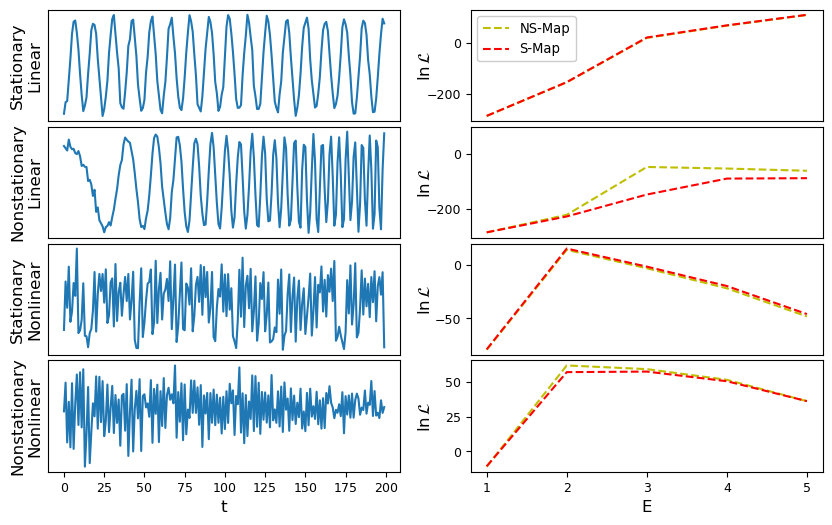

In [151]:
vfig, vax = plt.subplots(4, 2, figsize=(10,6))
fsize = 12
text_padding = 0.01
label_pad = -0.15

E_range = range(params["E_range"][0]+1, params["E_range"][1]+1)

labelnames = ['(a)','(b)','(c)','(d)','(e)','(f)','(g)','(h)','(i)','(j)','(k)','(l)']

# for series, ax in zip((statlin, nonstatlin, statlog, nonstatlog), vax.flatten()):
for ax_row, i in zip(vax, np.arange(4)):
    
    series, t, likelihood_s, likelihood_ns = stuff_dict[names[i]]

    ax_row[0].plot(series)
    ax_row[0].set_yticks([])
    ax_row[0].set_ylabel(names[i], size=fsize)
    ax_row[0].tick_params(axis='both', which='major', labelsize=fsize * 3 / 4)
    if i == 3:
        ax_row[0].set_xlabel(r"t", size=fsize)
    else:
        ax_row[0].set_xticks([])

    minLine = (np.log(likelihood_s) * 0)+min(min(np.log(likelihood_s)),min(np.log(likelihood_ns))) 

    ax_row[1].plot(E_range, np.log(likelihood_ns), "y--", label=r"NS-Map")
    # ax_row[1].fill_between(E_range, np.log(likelihood_ns), minLine, color = "yellow")
    ax_row[1].plot(E_range, np.log(likelihood_s), "r--", label=r"S-Map")
    # ax_row[1].fill_between(E_range, np.log(likelihood_s), minLine, color="orange")
    ax_row[1].set_xticks(E_range)
    if i != 3:
        ax_row[1].set_xticks([])
    else:
        ax_row[1].set_xlabel("E", size = fsize)
    if i == 1:
        ax_row[1].set_ylim([minLine[0]-20, 100])
    ax_row[1].tick_params(axis='both', which='major', labelsize=fsize * 3 / 4)

    ax_row[1].text(label_pad, 0.5, r"$\ln\mathcal{L}$", size=fsize, rotation = 90, 
            horizontalalignment="left",verticalalignment="center",
            transform=ax_row[1].transAxes)

    """
    divider = make_axes_locatable(ax_row[1])
    bax = divider.append_axes('top', size='100%', pad=0)
    
    # bax.plot(E_range, table[:,0], label=r"$\hat{\delta}$", color="green")
    # bax.plot(E_range, table[:,3], label=r"$\hat{\theta}$", color="silver")
    bax.set_xticks([])
    bax.tick_params(axis='both', which='major', labelsize=fsize * 3 / 4)
    
    ax_row[0].text(text_padding, 1-text_padding*2, f"{labelnames[3*i]}", size=fsize, fontweight="bold",
           horizontalalignment="left", verticalalignment="top",
           transform=ax_row[0].transAxes)
    bax.text(text_padding, 1-text_padding*4, f"{labelnames[3*i+1]}", size=fsize, fontweight="bold",
           horizontalalignment="left",verticalalignment="top",
           transform=bax.transAxes)
    bax.text(label_pad, 0.5, r"Parameter", size=fsize,
           horizontalalignment="left", verticalalignment="center", rotation = 90,
           transform=bax.transAxes)
    ax_row[1].text(text_padding, 1-text_padding*4, f"{labelnames[3*i+2]}", size=fsize, fontweight="bold",
           horizontalalignment="left",verticalalignment="top",
           transform=ax_row[1].transAxes)
    ax_row[1].text(label_pad, 0.5, r"$\ln\mathcal{L}$", size=fsize, rotation = 90, 
           horizontalalignment="left",verticalalignment="center",
           transform=ax_row[1].transAxes)
        """

    if i == 0:
        bax.legend(fontsize = fsize - 2.5, framealpha=1)
        bax.set_yticks([0])
        ax_row[1].legend(fontsize = fsize - 2.5, framealpha=1)
        
plt.subplots_adjust(wspace=0.2,
                    hspace=0.05)
# plt.savefig(f"../figures_eps/Figure_1.eps", format="eps", bbox_inches="tight", transparent=False)

# Delta vs Theta (Figure 2)

In [ ]:
# fill with data of results for Hastings Powell and Logistic in Round 2
# l_data = np.loadtxt("simulation_results_final\logistic_NSMap_vs_DLM.csv",delimiter=',')
# fc_data = np.loadtxt("simulation_results_final\hastings_powell_NSMap_vs_DLM.csv",delimiter=',')
# lin_data = np.loadtxt("simulation_results_final\linear_NSMap_vs_DLM.csv",delimiter=',')
lin_data = np.loadtxt("simulated_round_1_linear.csv",delimiter=',')
l_data = np.loadtxt("simulated_round_1_logistic.csv",delimiter=',')
fc_data = np.loadtxt("simulated_round_1_food_chain.csv",delimiter=',')

l_nonstat = np.log(l_data[l_data[:,0] == 1][:,1:3]+1)
l_stat = np.log(l_data[l_data[:,0] == 0][:,1:3]+1)
fc_nonstat = np.log(fc_data[fc_data[:,0] == 1][:,1:3]+1)
fc_stat = np.log(fc_data[fc_data[:,0] == 0][:,1:3]+1)
lin_nonstat = np.log(lin_data[lin_data[:,0] == 1][:,1:3]+1)
lin_stat = np.log(lin_data[lin_data[:,0] == 0][:,1:3]+1)

In [ ]:
np.sum(np.all(lin_stat == np.zeros(2), axis=1))

77

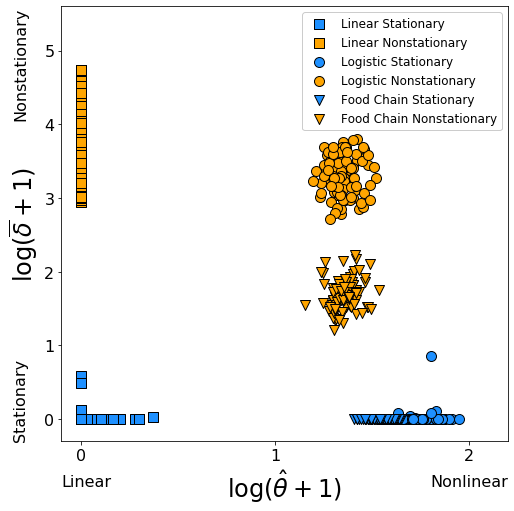

In [ ]:
size = 100
alpha = 1
dither = 0.02
fontsize_ticks = 16
fontsize_legend = 12
fontsize_axis = 24
fontsize_text = 16
text_padding = -0.075

dithering = lambda: rand.normal(0,dither,size=size)

dvt_fig, dvt_ax = plt.subplots(1, figsize=(8,8))
dvt_ax.set_xlabel(r"$\log(\hat{\theta}+1)$",fontsize=fontsize_axis)
dvt_ax.set_ylabel(r"$\log(\overline{\delta}+1)$",fontsize=fontsize_axis)
# dvt_ax.set_xticks([0,1.75])
dvt_ax.text(text_padding, 1, "Nonstationary", size=fontsize_text, rotation=90, 
            horizontalalignment="right", verticalalignment="top",
            transform=dvt_ax.transAxes)
dvt_ax.text(text_padding, 0, "Stationary", size=fontsize_text, rotation=90,
           horizontalalignment="right",verticalalignment="bottom",
           transform=dvt_ax.transAxes)
dvt_ax.text(0, text_padding, "Linear", size=fontsize_text,
           horizontalalignment="left",verticalalignment="top",
           transform=dvt_ax.transAxes)
dvt_ax.text(1, text_padding, "Nonlinear", size=fontsize_text,
           horizontalalignment="right",verticalalignment="top",
           transform=dvt_ax.transAxes)

dvt_ax.scatter(lin_stat[:,1], lin_stat[:,0], 
               c="dodgerblue",marker="s", s=size, edgecolors="black", 
               label="Linear Stationary", alpha=alpha)
dvt_ax.scatter(lin_nonstat[:,1], lin_nonstat[:,0], 
               c="orange",marker="s", s=size, edgecolors="black", 
               label="Linear Nonstationary", alpha=alpha)
dvt_ax.scatter(l_stat[:,1], l_stat[:,0], 
               c="dodgerblue", s=size, edgecolors="black", 
               label="Logistic Stationary", alpha=alpha)
dvt_ax.scatter(l_nonstat[:,1], l_nonstat[:,0], 
               c="orange", s=size, edgecolors="black", 
               label="Logistic Nonstationary", alpha=alpha)
dvt_ax.scatter(fc_stat[:,1], fc_stat[:,0], 
               c="dodgerblue",marker="v", s=size, edgecolors="black", 
               label="Food Chain Stationary", alpha=alpha)
dvt_ax.scatter(fc_nonstat[:,1], fc_nonstat[:,0], 
               c="orange",marker="v", s=size, edgecolors="black", 
               label="Food Chain Nonstationary", alpha=alpha)

dvt_ax.set_xlim([-0.1,2.2])
dvt_ax.set_ylim([-0.3,5.6])
dvt_ax.set_xticks([0,1,2])

plt.xticks(fontsize=fontsize_ticks, rotation=0)
plt.yticks(fontsize=fontsize_ticks, rotation=0)
plt.legend(prop={"size":fontsize_legend}, framealpha=1)
plt.savefig(f"../figures_eps/round1_results/Figure_2.eps", format="eps", bbox_inches="tight", transparent=False)

## NSMap vs DLM (Figure 3)

In [ ]:
lin_data = np.loadtxt("../results/round1_results/linear_NSMap_vs_DLM.csv",delimiter=',')
l_data = np.loadtxt("../results/round1_results/logistic_NSMap_vs_DLM.csv",delimiter=',')
fc_data = np.loadtxt("../results/round1_results/food_chain_NSMap_vs_DLM.csv",delimiter=',')

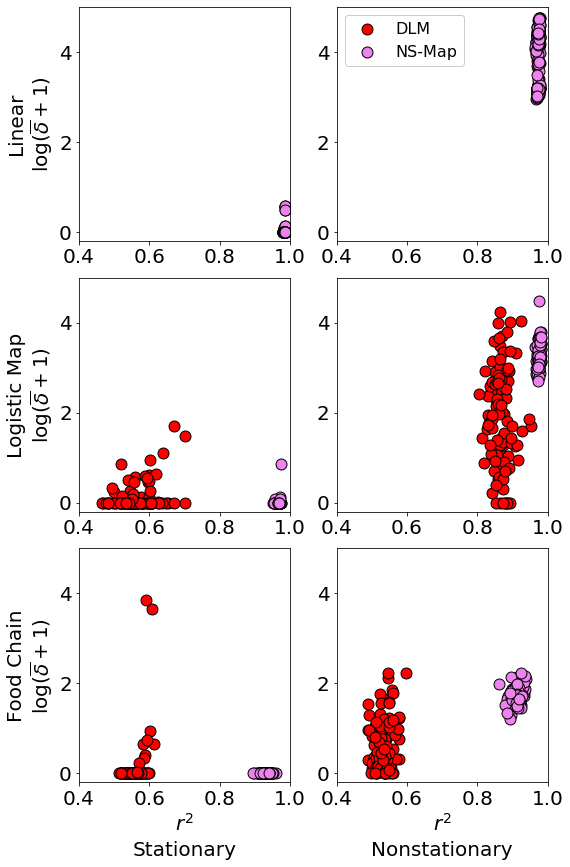

In [ ]:
vfig, vax = plt.subplots(3,2,figsize=(8,12))
B=40
size = 120
fontsize_axis = 20
fontsize_ticks = 20
fontsize_text = 20

text_padding_y = -0.25
text_padding_x = -0.25

dithering = lambda : rand.normal(0,0.05,100)

for m, model in enumerate(["lin", "l", "fc"]):
    data = locals()[model + "_" + "data"]
    for s, status in enumerate(["none", "fast"]):
        datap = data[data[:,0] == s]
        vax[m,min(1,s)].scatter(datap[:,5], np.log(datap[:,4]+1),
                         color="red",s=size, 
                         edgecolors="black",
                         alpha=1,label="DLM")
        vax[m,min(1,s)].scatter(datap[:,3], np.log(datap[:,1]+1),
                         color="violet",s=size, 
                         edgecolors="black",
                         alpha=1,label="NS-Map")

        vax[m,min(1,s)].set_xlim([0.4,1])
        vax[m,min(1,s)].set_ylim([-0.2,5])
        vax[m,min(1,s)].tick_params(axis='both',which='major',
                             labelsize=fontsize_ticks)

for i in range(3):
    vax[i,0].set_ylabel(r"$\log(\overline{\delta}+1)$",size=fontsize_axis)
for i in range(2):
    vax[2,i].set_xlabel(r"$r^2$",size=fontsize_axis)


vax[0,0].text(text_padding_y, 0.5, "Linear", rotation=90,
              verticalalignment="center", horizontalalignment="right",
              transform=vax[0,0].transAxes,size=fontsize_text)
vax[1,0].text(text_padding_y, 0.5, "Logistic Map", rotation=90,
              verticalalignment="center", horizontalalignment="right",
              transform=vax[1,0].transAxes,size=fontsize_text)
vax[2,0].text(text_padding_y, 0.5, "Food Chain", rotation=90,
              verticalalignment="center", horizontalalignment="right",
              transform=vax[2,0].transAxes,size=fontsize_text)
vax[2,0].text(0.5, text_padding_x, "Stationary",
              verticalalignment="top", horizontalalignment="center",
              transform=vax[2,0].transAxes,size=fontsize_text)
vax[2,1].text(0.5, text_padding_x, "Nonstationary", 
              verticalalignment="top", horizontalalignment="center",
              transform=vax[2,1].transAxes,size=fontsize_text)
# vax[2,2].text(0.5, text_padding_x, "Fast Nonstationary", 
#               verticalalignment="top", horizontalalignment="center",
#               transform=vax[2,2].transAxes,size=fontsize_text)

vax[0,1].legend(fontsize=16, framealpha=1)
plt.tight_layout()
# plt.savefig("../Figures/round1_NSMap_vs_DLM.png", dpi=300)
plt.savefig("../figures_eps/round1_results/Figure_3.eps", format="eps", bbox_inches="tight", transparent = False)

In [ ]:
# Compute the increase in forecast skill for nonlinear models from SMap to NSMap,
# averaging over all nonstationary categories

print(f"Logistic NSMap r_sqrd = {np.mean(l_data[:,3])}")
print(f"Logistic SMap r_sqrd = {np.mean(l_data[:,5])}")
print(f"Food Chain NSMap r_sqrd = {np.mean(fc_data[:,3])}")
print(f"Food Chain SMap r_sqrd = {np.mean(fc_data[:,5])}")

Logistic NSMap r_sqrd = 0.9705834999999999
Logistic SMap r_sqrd = 0.7155315
Food Chain NSMap r_sqrd = 0.9205930000000001
Food Chain SMap r_sqrd = 0.5459945
